# Kaggriculture: What's Actually Worth Doing With a Turn

**The scarce resource is not land or money. It's actions — and there are exactly 720.**

Reading the rules, one asymmetry stands out and seems to decide most of the strategy:

> Each turn, the player may take one action. There are 24 turns per day, and 30 days.
>
> Each turn you can submit up to `maxMarketOrdersPerTurn` (**default 10**) market actions.

A farmer gets **one** action per turn. The market accepts **ten**. So buying and selling is
effectively free, while planting, watering and harvesting are not. Land is capped at 100
tiles and money is recoverable, but a spent turn is gone.

That makes **profit per action** the number that ranks strategies — not profit per tile,
not margin, not payback period.

This notebook computes it for every crop and animal in the spec. Everything below is
derived in-notebook from constants transcribed out of the competition README; where a
rule is ambiguous I say so and show the alternative rather than picking silently.

**Headline:** melons return roughly **9× wheat per action**, and a cared-for sheep is
competitive with melon while needing no replanting. Details, caveats and the arithmetic
follow.

In [1]:
from dataclasses import dataclass, field
import math
import matplotlib.pyplot as plt
import numpy as np

TURNS_PER_DAY, DAYS = 24, 30
TOTAL_ACTIONS = TURNS_PER_DAY * DAYS
print(f"Season budget: {TURNS_PER_DAY} turns/day x {DAYS} days = {TOTAL_ACTIONS} farmer actions")
print("Market orders are separate (10/turn), so BUY/SELL cost no farmer actions.")

Season budget: 24 turns/day x 30 days = 720 farmer actions
Market orders are separate (10/turn), so BUY/SELL cost no farmer actions.


## 1. The spec, as data

Transcribed from the competition README. Keeping it as a table rather than prose means
every downstream number is recomputed if a constant is wrong — and if you think one *is*
wrong, you can change it here and rerun rather than re-deriving by hand.

In [2]:
@dataclass
class Crop:
    name: str
    seed_cost: int
    price: int          # base market price per unit
    max_yield_day: int  # age at which the yield bonus stops accruing
    max_yield: int      # cap on harvestable units (unfertilized figure in the README)
    ongoing: bool = False
    yield_interval: int = 0   # days between scheduled productions (ongoing only)
    n_yields: int = 0         # number of scheduled productions before decay

# One-time crops. README: "Wheat and Carrot only reach their listed Max Yield of 6 and 4
# with fertilizer; watering alone peaks at 4 and 3." So max_yield here is the watered-only
# figure, which is what the no-fertilizer baseline should use.
CROPS = [
    Crop("Wheat",      10,  25, max_yield_day=4,  max_yield=4),
    Crop("Carrot",     20,  35, max_yield_day=3,  max_yield=3),
    Crop("Melon",      80, 250, max_yield_day=12, max_yield=6),
    Crop("Tomato",     50,  60, max_yield_day=11, max_yield=4, ongoing=True, yield_interval=1, n_yields=4),
    Crop("Strawberry",100, 120, max_yield_day=16, max_yield=4, ongoing=True, yield_interval=2, n_yields=4),
]

@dataclass
class Animal:
    name: str
    cost: int
    price: int          # price per unit of product
    first_yield_day: int
    interval: int       # days between scheduled productions
    max_held: int       # cap on unharvested units on the tile
    build_actions: int = 2   # BUILD_COOP/PASTURE + PLACE

ANIMALS = [
    Animal("Goose/Egg",  300,  50, first_yield_day=4, interval=1, max_held=4),
    Animal("Cow/Milk",   400, 160, first_yield_day=8, interval=2, max_held=6),
    Animal("Sheep/Wool", 500, 200, first_yield_day=6, interval=3, max_held=6),
]

for c in CROPS: print(f"{c.name:<11} seed {c.seed_cost:>4}  price {c.price:>4}")
for a in ANIMALS: print(f"{a.name:<11} cost {a.cost:>4}  price {a.price:>4}  every {a.interval}d")

Wheat       seed   10  price   25
Carrot      seed   20  price   35
Melon       seed   80  price  250
Tomato      seed   50  price   60
Strawberry  seed  100  price  120
Goose/Egg   cost  300  price   50  every 1d
Cow/Milk    cost  400  price  160  every 2d
Sheep/Wool  cost  500  price  200  every 3d


## 2. Counting the actions a crop really costs

Three action types per one-time crop: one `PLANT`, one `HARVEST`, and however many
`WATER`s. The waterings are where it gets interesting, because two different rules apply:

- **Survival.** A plant that goes two consecutive days unwatered becomes a weed. So you
  must water at least every other day. Note the README's trap: *"A new seed starts with
  `consecutive_unwatered = 1` — the planting day itself counts as the first missed day."*
  You must water on the day you plant, or it dies that night.
- **Yield.** *"Starting at half the plant's `max_yield_day` rounded up, watering during
  the bonus window will add one unit per day."* Only waterings inside that window add yield.

So the cheapest way to a full harvest is: water on planting day, water every *other* day
to stay alive, then water *every* day once the bonus window opens.

In [3]:
def watering_days(crop):
    """Minimum set of days to water for max yield: survive, then saturate the window."""
    window_start = math.ceil(crop.max_yield_day / 2)
    # Yield is base 1 plus one unit per watered day in the window, capped at max_yield.
    days_needed_in_window = min(crop.max_yield - 1, crop.max_yield_day - window_start + 1)
    harvest_day = window_start + days_needed_in_window - 1

    days = {0}                                    # planting day is mandatory
    days |= set(range(window_start, harvest_day + 1))   # daily through the window
    d = 0                                          # every-other-day survival before the window
    while d < window_start:
        days.add(d); d += 2
    return sorted(days), harvest_day

print(f"{'crop':<11} {'window':<9} {'harvest':<8} {'waters':<7} yield")
for c in CROPS:
    if c.ongoing: continue
    w, h = watering_days(c)
    print(f"{c.name:<11} day {math.ceil(c.max_yield_day/2):<5} {h:<8} {len(w):<7} {min(c.max_yield, 1+sum(1 for d in w if d>=math.ceil(c.max_yield_day/2)))}")

crop        window    harvest  waters  yield
Wheat       day 2     4        4       4
Carrot      day 2     3        3       3
Melon       day 6     10       8       6


Sanity check against the README, which states the answers for two crops: wheat should peak
at **4** units on watering alone and carrot at **3**. If the model above disagrees with
those, the model is wrong — so it is worth checking rather than assuming.

In [4]:
def one_time_yield(crop):
    w, _ = watering_days(crop)
    window_start = math.ceil(crop.max_yield_day / 2)
    bonus = sum(1 for d in w if d >= window_start)
    return min(crop.max_yield, 1 + bonus)

checks = {"Wheat": 4, "Carrot": 3, "Melon": 6}
ok = True
for c in CROPS:
    if c.name in checks:
        got, want = one_time_yield(c), checks[c.name]
        flag = "OK " if got == want else "MISMATCH"
        if got != want: ok = False
        print(f"  {flag} {c.name:<8} model={got}  README={want}")
print("\nmodel reproduces the README's stated yields" if ok else "\nMODEL DISAGREES WITH SPEC — trust the spec, not this notebook")

  OK  Wheat    model=4  README=4
  OK  Carrot   model=3  README=3
  OK  Melon    model=6  README=6

model reproduces the README's stated yields


## 3. Profit per action

Now the actual ranking. For one-time crops: `(units x price - seed) / (plant + waters + harvest)`.

For ongoing crops and animals the shape differs — they produce repeatedly, so the fair
comparison is over their full productive life, including the setup actions.

For animals I model two regimes, because `CARE` changes the picture completely:

- **Feed-only**: `FEED` daily, `HARVEST` on production days. One unit per production.
- **Feed + care**: also `CARE` daily, which banks +1 per day and pays the whole bank out
  on the next production, capped by `max_held`.

In [5]:
def crop_profit_per_action(crop):
    if not crop.ongoing:
        w, harvest_day = watering_days(crop)
        actions = 1 + len(w) + 1                       # PLANT + WATERs + HARVEST
        units = one_time_yield(crop)
        profit = units * crop.price - crop.seed_cost
        return profit / actions, actions, units, harvest_day
    # Ongoing: base 1 per scheduled production, water daily to survive/keep it alive.
    last_day = crop.max_yield_day
    waters = len({0} | set(range(0, last_day + 1, 2)))
    actions = 1 + waters + crop.n_yields               # PLANT + WATERs + one HARVEST each
    units = crop.n_yields
    profit = units * crop.price - crop.seed_cost
    return profit / actions, actions, units, last_day

def animal_profit_per_action(a, care, horizon_days=None):
    """Actions and profit over the animal's productive window within the season."""
    horizon = horizon_days if horizon_days else DAYS
    prod_days = list(range(a.first_yield_day, horizon + 1, a.interval))
    if not prod_days: return 0.0, 0, 0
    feed = horizon - 0                                  # FEED every day it is alive
    care_actions = feed if care else 0
    harvests = len(prod_days)
    actions = a.build_actions + feed + care_actions + harvests

    if not care:
        units = harvests                                # base 1 each
    else:
        # Bank +1 per cared day between productions, paid out at the next production,
        # capped by max_held.
        units, bank = 0, 0
        for d in range(1, horizon + 1):
            bank += 1                                   # fed AND cared this day
            if d in prod_days:
                units += min(1 + bank, a.max_held); bank = 0
    profit = units * a.price - a.cost
    return profit / actions, actions, units

rows = []
for c in CROPS:
    ppa, act, units, _ = crop_profit_per_action(c)
    rows.append((c.name, ppa, act, units, "crop"))
for a in ANIMALS:
    for care in (False, True):
        ppa, act, units = animal_profit_per_action(a, care)
        rows.append((f"{a.name}{' +CARE' if care else ''}", ppa, act, units, "animal"))

rows.sort(key=lambda r: -r[1])
print(f"{'strategy':<20} {'$/action':>9} {'actions':>8} {'units':>6}")
print("-" * 47)
for name, ppa, act, units, _ in rows:
    print(f"{name:<20} {ppa:>9.1f} {act:>8} {units:>6}")

strategy              $/action  actions  units
-----------------------------------------------
Melon                    142.0       10      6
Sheep/Wool +CARE         100.0       71     38
Cow/Milk +CARE            78.9       74     39
Cow/Milk                  34.5       44     12
Sheep/Wool                31.7       41      9
Goose/Egg +CARE           28.1       89     56
Strawberry                27.1       14      4
Goose/Egg                 17.8       59     27
Tomato                    17.3       11      4
Carrot                    17.0        5      3
Wheat                     15.0        6      4


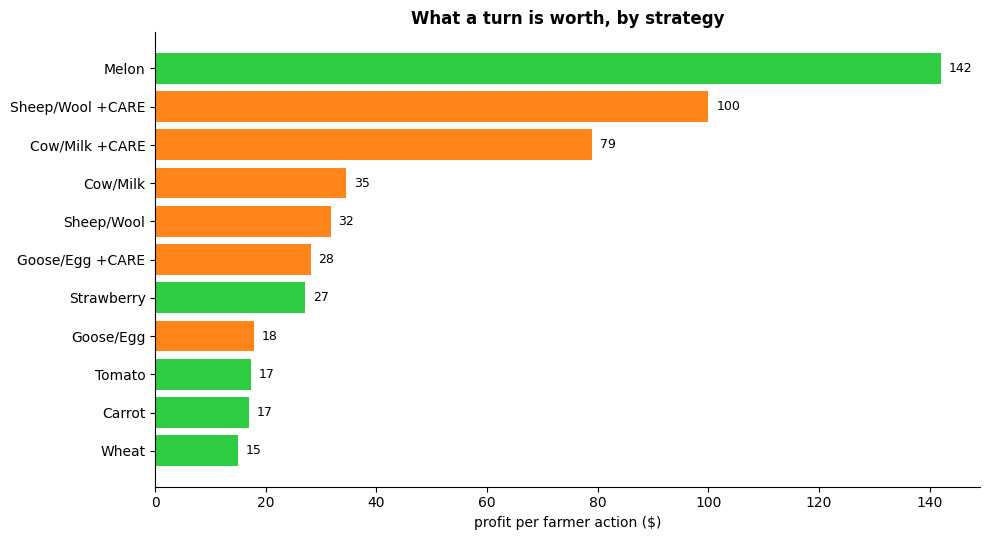

In [6]:
names = [r[0] for r in rows][::-1]
vals  = [r[1] for r in rows][::-1]
cols  = ["#2ECC40" if r[4] == "crop" else "#FF851B" for r in rows][::-1]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(names, vals, color=cols)
ax.set_xlabel("profit per farmer action ($)")
ax.set_title("What a turn is worth, by strategy", fontweight="bold")
for i, v in enumerate(vals):
    ax.text(v + max(vals) * 0.01, i, f"{v:.0f}", va="center", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 4. What this says

Read the chart as a ranking of *what to do with your next turn*, not as a profit forecast.

The gap between the top and bottom is roughly an order of magnitude, which is larger than
most strategic decisions in the game. A player spending turns on wheat while an opponent
spends them on melons is losing ground every single turn, regardless of how well either
plays otherwise.

Three caveats that matter, and none of them are small:

1. **The market is dynamic.** All prices above are the README's *base* prices. Dumping six
   melons at once will move the price against you, and the size of that move is not in the
   spec — it has to be measured in-game. Treat the ranking as an upper bound and a
   priority order, not a revenue estimate.
2. **Wheat is not competitive as a cash crop, but animals eat it.** Every animal needs
   wheat daily. Wheat's value is as feedstock, and the real comparison is growing it versus
   buying it at market price — a different question from the one this notebook answers.
3. **Time-to-first-yield gates everything early.** Melon takes 10 days to first harvest out
   of a 30-day season, and a sheep takes 6 before it produces anything. With 300–500 up
   front and no income, the opening is a cash-flow problem, not an efficiency problem.

The honest summary: **this tells you what to do with turn 400. It does not tell you what
to do with turn 1.** The opening — how to convert seed money into the first melon or the
first animal without starving — is the harder problem, and it is not solved here.

---

*Every figure recomputed in-notebook from constants transcribed out of the competition
README; the model is checked against the two yields the README states outright. If you
think a constant or a rule reading is wrong, the table in section 1 is the only place to
change it — say so in the comments and I'll fix it.*